# Analysis of E. Coli Bacteria vs Klebsiella Pneumoniae Bacteria with CNN

In [1]:
%load_ext autoreload
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from numpy import loadtxt
from scipy.fftpack import fft
from scipy.fft import fft, ifft, fftfreq
from numpy import arange
from skimage.measure import EllipseModel
from matplotlib.patches import Ellipse
from scipy.signal import savgol_filter
from random import randint
%run data_import_to_create_databases.ipynb
%run functions_master_file.ipynb

empty_drums_30: Empty cavities has 828 cases.
empty_drums_graph: Empty drums has 928 cases.
ecoli_CTR: Control cases has 1130 cases.
ecoli_WA_subs: E. Coli susceptible has 380 cases.
ecoli_WA_resis: E. Coli resistant has 207 cases.
ecoli_WA_total: All E. Coli with antibiotics has 587 cases.
intact_drums: Intact drums has 2645 cases.
bacteria_all: All E. Coli data has 1717 cases.
Therefore, all data has 3473 cases.

For cases with other bacteria:

kpneumoniae_KPC2_CTR: All Klabsiella Pneumoniae data has 526 cases.
Paeruginosa_L1171_CTR: All Pseudomonas aeruginosa data has 95 cases.
abaumannii_B1380_CTR: All Acinetobacter Baumannii data has 106 cases.
S_aureus_CTR: All Staphylococcus Aureus data has 204 cases.
senteriditis_S1400_CTR: All Salmonella Enteritidis data has 198 cases.
Sagalactiae_CTR: All Streptococcus Agalactiae data has 100 cases.


## Flatten and Fix data arround zero

In [2]:
ecoli_control_array, _ = flatten_fix_n_filter_data(ecoli_CTR, tf = ecoli7744_CTR_df['Time [s]'][0], 
                threshold_range = [60.577249648120258, 4000], flatten = True, filter_by_variance = True)

kpneumoniae_control_array, _ = flatten_fix_n_filter_data(kpneumoniae_KPC2_CTR, tf = ecoli7744_CTR_df['Time [s]'][0], 
                threshold_range = [0.7258486742156691, 1.6755682484293741], flatten = True, filter_by_variance = True)

S_aureus_control_array, _ = flatten_fix_n_filter_data(S_aureus_CTR, tf = ecoli7744_CTR_df['Time [s]'][0], 
                threshold_range = [2, 45.577249648120258], flatten = True, filter_by_variance = True)

The data used has a shape of (150, 60000)
The data used has a shape of (211, 60000)
The data used has a shape of (95, 60000)


## Split data in Train and Test datasets

In [ ]:
case1 = ecoli_control_array
case2 = kpneumoniae_control_array 
case3 = S_aureus_control_array

case1_index = 4*len(case1) // 5 #20% is for testing
case2_index = 4*len(case2) // 5 #20% is for testing
case3_index = 4*len(case3) // 5 #20% is for testing

train_data = np.vstack((case1[:case1_index], case2[:case2_index], case3[:case3_index]))
test_data = np.vstack((case1[-(len(case1)-case1_index):], case2[-(len(case2)-case2_index):], case3[-(len(case3)-case3_index):]))

train_labels = np.hstack((np.zeros(train_data[:case1_index].shape[0]), np.ones(train_data[:case2_index].shape[0]), (2*np.ones(train_data[:case3_index].shape[0]))))
test_labels = np.hstack((np.zeros(test_data[-(len(case1)-case1_index):].shape[0]), np.ones(test_data[-(len(case2)-case2_index):].shape[0]), (2*np.ones(test_data[-(len(case3)-case3_index):].shape[0]))))

train_images, train_vmin, train_vmax, train_freqs  = get_all_Pxx_matrices(train_data, 
            tf=ecoli7744_CTR_df['Time [s]'][0], limit_Pxx_height= 32,
            nperseg_val = 2**9, noverlap_val = ((2**9)/(2)), find_scale = 'average_minmax',
            same_color_scale=True, log_scale=True)

test_images, test_vmin, test_vmax, test_freqs  = get_all_Pxx_matrices(test_data, 
            tf=ecoli7744_CTR_df['Time [s]'][0], limit_Pxx_height= 32,
            nperseg_val = 2**9, noverlap_val = ((2**9)/(2)), find_scale = 'average_minmax', 
            same_color_scale=True, log_scale=True)

In [4]:
print('A dataset of ' + str(train_images.shape[0]+test_images.shape[0]) + ' measurements is used.')
print('')
print(str(train_images.shape[0]) + ' are used for training with a shape of ' + str(train_images.shape[-3:]))
print('Case 1 in traning has ' + str(case1_index) + ' cases.')
print('Case 2 in traning has ' + str(case2_index) + ' cases.')
print('Case 3 in traning has ' + str(case3_index) + ' cases.')
print('')
print(str(test_images.shape[0]) + ' are used for testing with a shape of ' + str(test_images.shape[-3:]))
print('Case 1 in testing has ' + str((len(case1)-case1_index)) + ' cases.')
print('Case 2 in testing has ' + str((len(case2)-case2_index)) + ' cases.')
print('Case 3 in testing has ' + str((len(case3)-case3_index)) + ' cases.')

A dataset of 456 measurements is used.

364 are used for training with a shape of (234, 234, 4)
Case 1 in traning has 120 cases.
Case 2 in traning has 168 cases.
Case 3 in traning has 76 cases.

92 are used for testing with a shape of (234, 234, 4)
Case 1 in testing has 30 cases.
Case 2 in testing has 43 cases.
Case 3 in testing has 19 cases.


### Checking the first 10 generated images

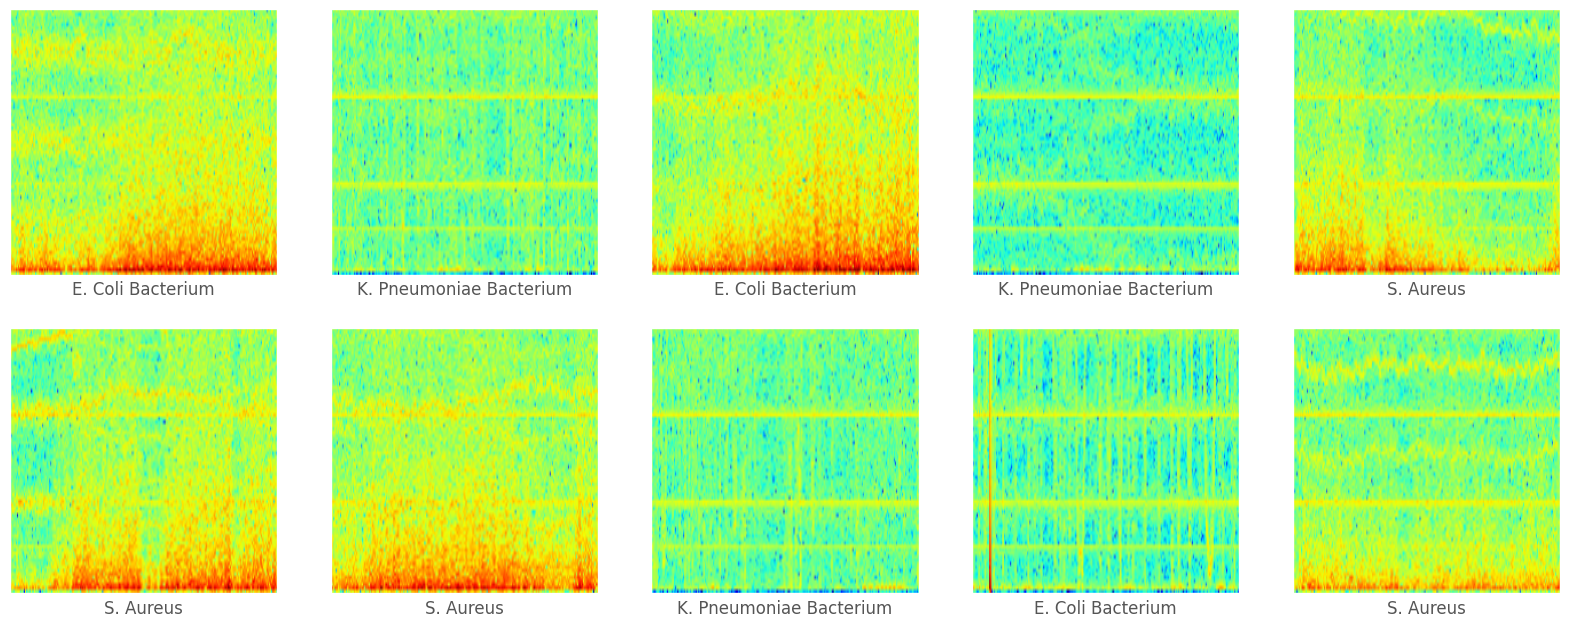

In [5]:
test_before_norm = get_some_img_in_arrays(test_images, test_labels, num_img = 10, 
                            class_names = ['E. Coli Bacterium', 'K. Pneumoniae Bacterium', 'S. Aureus'],
                            colorbar_active = False, grayscale_active = False,
                            vmin_val = None, vmax_val = None)

## Convolutional Neural Network Architecture and training

In [ ]:
train_images = np.expand_dims(train_images, axis=-1)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model_CNN = models.Sequential()

model_CNN.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(train_images.shape[1], train_images.shape[2], train_images.shape[3])))
model_CNN.add(layers.MaxPooling2D((2, 2)))
model_CNN.add(layers.Dropout(0.2))

model_CNN.add(layers.Conv2D(32, (3, 3), activation='relu'))
model_CNN.add(layers.MaxPooling2D((2, 2)))
model_CNN.add(layers.Dropout(0.2))

model_CNN.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_CNN.add(layers.MaxPooling2D((2, 2)))
model_CNN.add(layers.Dropout(0.2))

model_CNN.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_CNN.add(layers.MaxPooling2D((2, 2)))
model_CNN.add(layers.Dropout(0.2))

model_CNN.add(layers.Flatten())
model_CNN.add(layers.Dense(64, activation='relu'))
model_CNN.add(layers.Dense(3, activation='softmax'))

model_CNN.summary()

opt = keras.optimizers.Adam(learning_rate=0.0001)

model_CNN.compile(optimizer=opt, 
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
             metrics=['accuracy'])

number_epochs =90

# Add data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True)

datagen.fit(train_images)

# fits the model on batches with real-time data augmentation:
history = model_CNN.fit(datagen.flow(train_images, train_labels, batch_size=32),
              epochs=number_epochs,
              validation_data=(test_images, test_labels))


/Users/santiago/python-arm64-py311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-14 12:07:50.938755: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2025-11-14 12:07:50.938790: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-11-14 12:07:50.938796: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2025-11-14 12:07:50.938816: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-14 12:07:50.938829: I tensorflow/core/common_runtime/pluggable_device/pluggable_dev

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 232, 232, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 116, 116, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 116, 116, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 114, 114, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 57, 57, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 57, 57, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 55, 55, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,939 (2.50 MB)

 Trainable params: 655,939 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

/Users/santiago/python-arm64-py311/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/90


2025-11-14 12:07:51.921840: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.4121 - loss: 1.2155 - val_accuracy: 0.4674 - val_loss: 1.0438
Epoch 2/90
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.5275 - loss: 0.9960 - val_accuracy: 0.7609 - val_loss: 1.0167
Epoch 3/90
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.5330 - loss: 0.9923 - val_accuracy: 0.7609 - val_loss: 0.9715
Epoch 4/90
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.6923 - loss: 0.8672 - val_accuracy: 0.7609 - val_loss: 0.8684
Epoch 5/90
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.7418 - loss: 0.7249 - val_accuracy: 0.7609 - val_loss: 0.6998
Epoch 6/90
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.7473 - loss: 0.6136 - val_accuracy: 0.7717 - val_loss: 0.5913
Epoch 7/90
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.7802 - loss: 0.5642 - val_accuracy: 0.8152 - val_loss: 0.5534
Epoch 8/90
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.7692 - loss: 0.5027 - val_accuracy: 0.8152 - val_

 ## Confirming the accuracy of the Neural network
 
 ### Plot for Accuracy vs Val_accuracy
 
 - The val_accuracy indicates the accuracy of the predictions of a randomly separated validation set after each training period

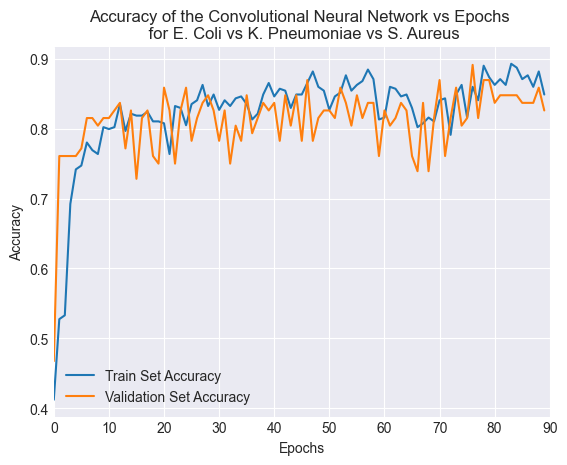

In [7]:
plot_accuracy_n_loss(model_history = history, epoch_num = number_epochs, 
        accuracy_plot = True, loss_plot = False, xlim = 'auto', ylim = 'auto', 
        title = 'Accuracy of the Convolutional Neural Network vs Epochs \n for E. Coli vs K. Pneumoniae vs S. Aureus',
        file_name = 'accuracy_plot_ecoli_vs_kpneu_CNN_saureus_epochs_90_6',
        dpi_val = 300, save = False)

### Loss vs epochs

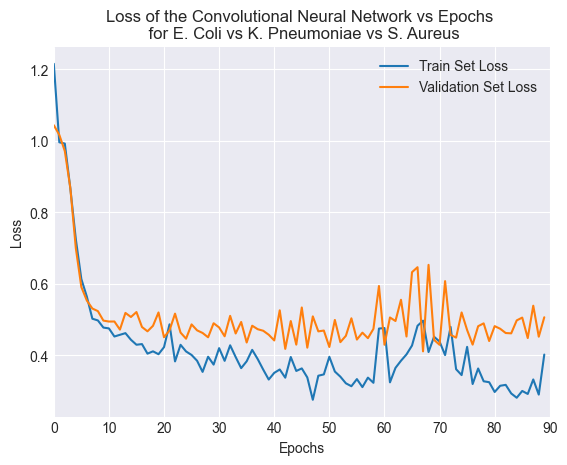

In [8]:
plot_accuracy_n_loss(model_history = history, epoch_num = number_epochs, 
        accuracy_plot = False, loss_plot = True, xlim = 'auto', ylim = 'auto', 
        title = 'Loss of the Convolutional Neural Network vs Epochs \n for E. Coli vs K. Pneumoniae vs S. Aureus',
        file_name = 'loss_plot_ecoli_vs_kpneu_CNN_saureus_epochs_90_6',
        dpi_val = 300, save = False)

## Confusion matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Raw confusion matrix:
 [[16  3 11]
 [ 0 43  0]
 [ 1  1 17]]


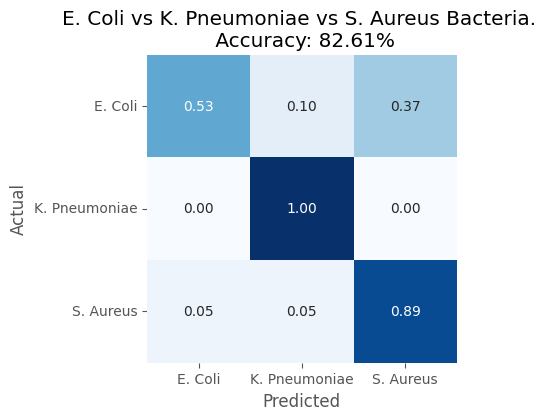

In [9]:
target_names = ['E. Coli', 'K. Pneumoniae', 'S. Aureus']

imgh, acc, y_predicted_labels = plot_conf_matrix(model_CNN, test_images, test_labels, algorithm_type = 'NN',
                        title = 'E. Coli vs K. Pneumoniae vs S. Aureus Bacteria', 
                        file_name = 'ecoli_CTR_vs_kpneumoniae_CTR_vs_Saureus_epochs_90_normalized_CNN_88.04', 
                        target_names = target_names, save = False, normalize = True) 


### Multiclass AUC Internal Analysis

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


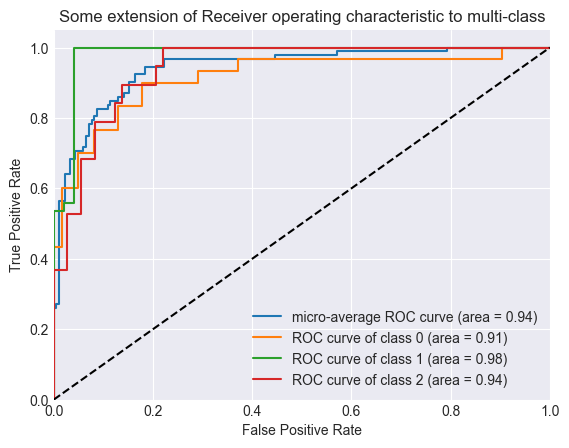

In [10]:
FPR_CNN_ecoli_kpneu_saureus,TPR_CNN_ecoli_kpneu_saureus,AUC_ROC_CNN_ecoli_kpneu_saureus = plot_multiclass_ROC_internal_analysis(model = model_CNN,
                            test_data = test_images, 
                            test_labels = test_labels, 
                            n_classes = 3,
                            title = 'for Susceptible E. Coli vs Resistant E. Coli (with antibiotics)', 
                            file_name = 'roc_CNN_SVM_Poly_4_NN_ecoli_WA_susc_ecoli_WA_resis_1', model_type = 'NN', model_names = ['CNN'],
                            models_dict = None, multiple_models = False, save = False)

### Save the model

In [ ]:
from tensorflow.keras.models import load_model

# model_svc.save('ecoli_CTR_vs_kpneumoniae_CTR_vs_Saureus_epochs_90_acc_98.h5')  # creates a HDF5 file 'my_model.h5'
from joblib import dump, load
# Save the model
# dump(model_CNN, 'CNN_model_ecoli_CTR_vs_kpneumoniae_CTR_vs_Saureus_epochs_90_acc_X.joblib')

# from keras.models import load_model
# model = load_model('my_model.h5')